<span style="color:Olive; font-size:40px">**ANNOTATION & Compositional Analysis**</span>

⚠️  <span style="color: orange; font-size:18px">***Restart Kernel***</span>

<span style="font-size:16px; font-weight:bold"> In this notebook, data will be normalized, integrated, and clustered. </span> 

<span style="font-size:14px; color:red; font-weight:bold"> <strong>Note:</strong> All newly created notebooks must include an initial cell for environment setup and memory usage management. </span>

<span style="color:olive; font-size:16px">**Import libraries**</span>

In [3]:
import scanpy as sc
import anndata as ad
import scanpy.external as sce
import numpy as np
import pandas as pd
import psutil, gc, os, zipfile
import scrublet as scr
import matplotlib.pyplot as plt
import matplotlib.backends.backend_pdf as pdf_backend
import seaborn as sns
from pathlib import Path
from scipy.sparse import issparse
from scipy.sparse import csr_matrix
from scipy.stats import median_abs_deviation
from tqdm import tqdm

In [4]:

sc.settings.n_jobs     = 4                  # Use multiple CPU cores for parallel processing (if supported by the function)
sc.settings.verbosity  = 2              # Set verbosity level (0 = errors only, 1 = warnings, 2 = info, 3 = debug)  
sc.settings.figdir     = '../results/'    # Directory to save figures
np.random.seed(42) 

raw_dir  = Path('../data/Raw_matrix')
ckpt_dir = Path('../checkpoints')
ckpt_dir.mkdir(exist_ok=True)


def check_ram():
    ram = psutil.Process().memory_info().rss / 1e9
    print(f"RAM in use: {ram:.1f} GB")
    if ram > 11:
        print("⚠️ High RAM — consider restarting kernel soon")

def find_matrix_folder(patient_dir):
    for subfolder in patient_dir.iterdir():
        if subfolder.is_dir() and any(subfolder.rglob('*.mtx*')):
            return subfolder
    return None

check_ram()

RAM in use: 0.4 GB


<span style="color:olive; font-size:22px">**Sanity Check: UMAP colored by total counts, mitochondrial content, and batch**</span>

<span style="font-size:14px">Before proceeding, we have to check the quality of our cleaned data. We will perform a "Sanity Check" Visualization to ensure that our clusters are driven by biology (cell types) and not by technical noise (residual doublets, high mitochondrial content, or batch effects) that might have survived the cleaning.</span>

computing neighbors
    finished (0:00:04)
computing UMAP
    finished (0:00:31)


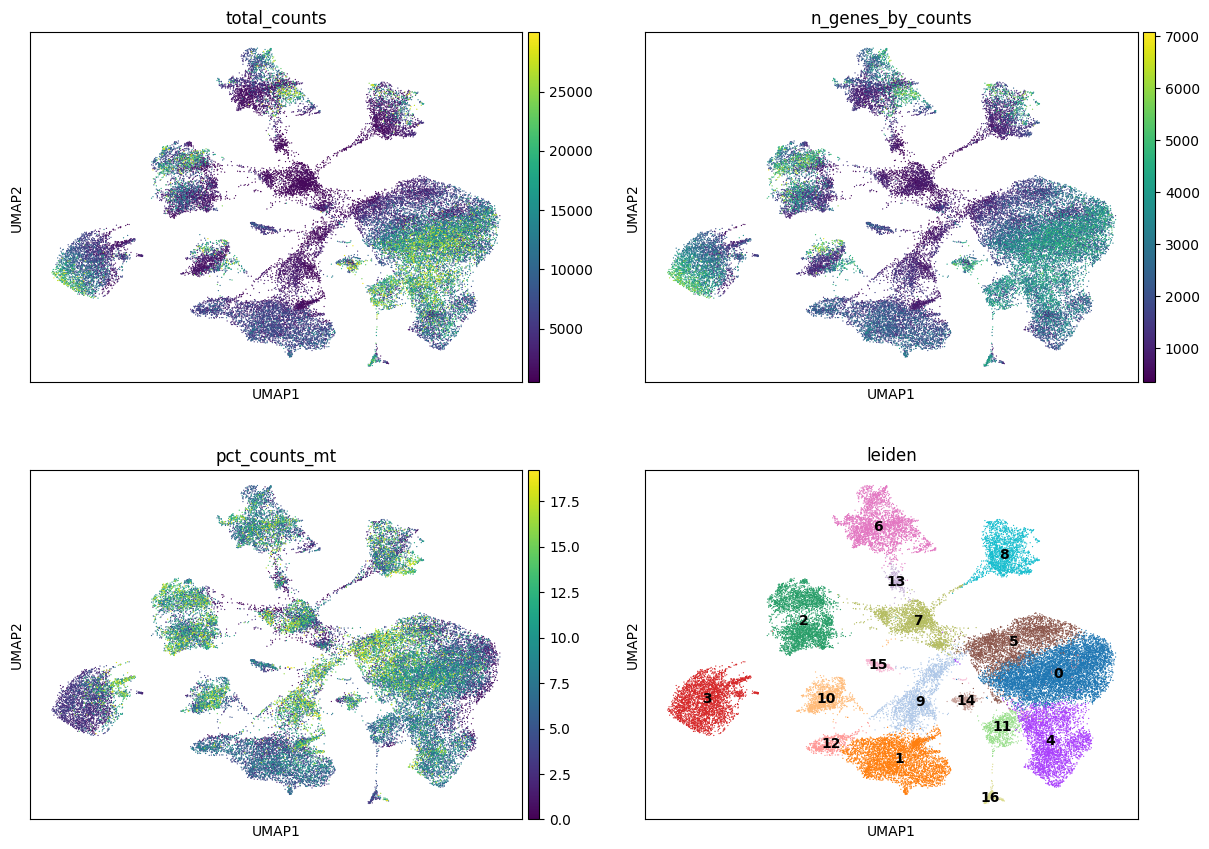

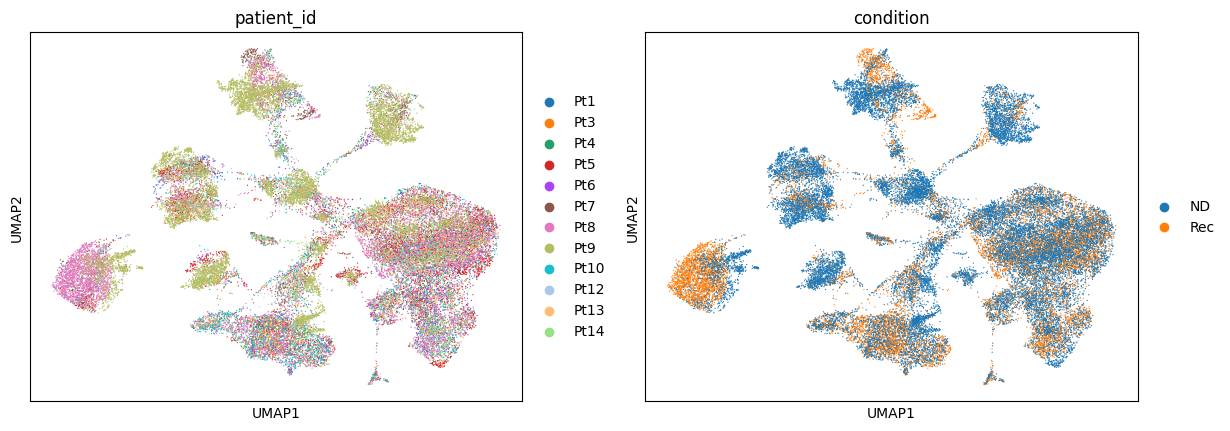

In [6]:
import scanpy as sc

# Load the clean data
adata = sc.read_h5ad(ckpt_dir / 'final_clean_adata.h5ad')

# 1. Re-calculate manifold on clean cells (Required for accuracy)
sc.pp.neighbors(adata, use_rep='X_pca_harmony', n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)

# 2. Plot QC metrics on UMAP (Section 11.4 of the guide)
# We want to see that these metrics are randomly distributed and not forming their own clusters
sc.pl.umap(adata, 
           color=['total_counts', 'n_genes_by_counts', 'pct_counts_mt', 'leiden'], 
           ncols=2, 
           cmap='viridis',
           legend_loc='on data', 
           save='_final_QC_check.pdf')

# 3. Check for Batch Mixing (Section 14)
# Ensure patients from both conditions are well-mixed within the same cell-type clusters
sc.pl.umap(adata, color=['patient_id', 'condition'], ncols=2, save='_final_integration_check.pdf')


   - <span style="color:teal; font-size:14px">**Quantitative metadata check** to see if the cleaning changed the proportions of cells from each patient or condition.</span>

In [7]:
print(adata.obs['condition'].value_counts())
print(f"\nFinal Genes: {adata.n_vars}")
print(f"Final Cells: {adata.n_obs}")


condition
ND     24965
Rec    12018
Name: count, dtype: int64

Final Genes: 25355
Final Cells: 36983


<span style="color:olive; font-size:22px">**Cell type annotation**</span>

<span style="font-size:14px">Before proceeding with the differential gene expression analysis, we need to annotate our clusters to know which cell types they correspond to. This is crucial for interpreting the results of the DGE analysis.</span>

1. <span style="color:olive; font-size:16px">**We need to examine the marker genes for each cluster to assign cell type labels.**</span>

In [9]:
print(adata.layers.keys())

KeysView(Layers with keys: raw_counts)


normalizing counts per cell
    finished (0:00:00)
Calculating marker genes per cluster...
ranking genes
    finished (0:01:02)


C:\Users\dioul\AppData\Local\Temp\ipykernel_44348\3731355468.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  markers_df = markers_df[markers_df['logfoldchanges'] > 1].groupby('group').head(20)  # Keep only top 20 markers per cluster with logFC > 1


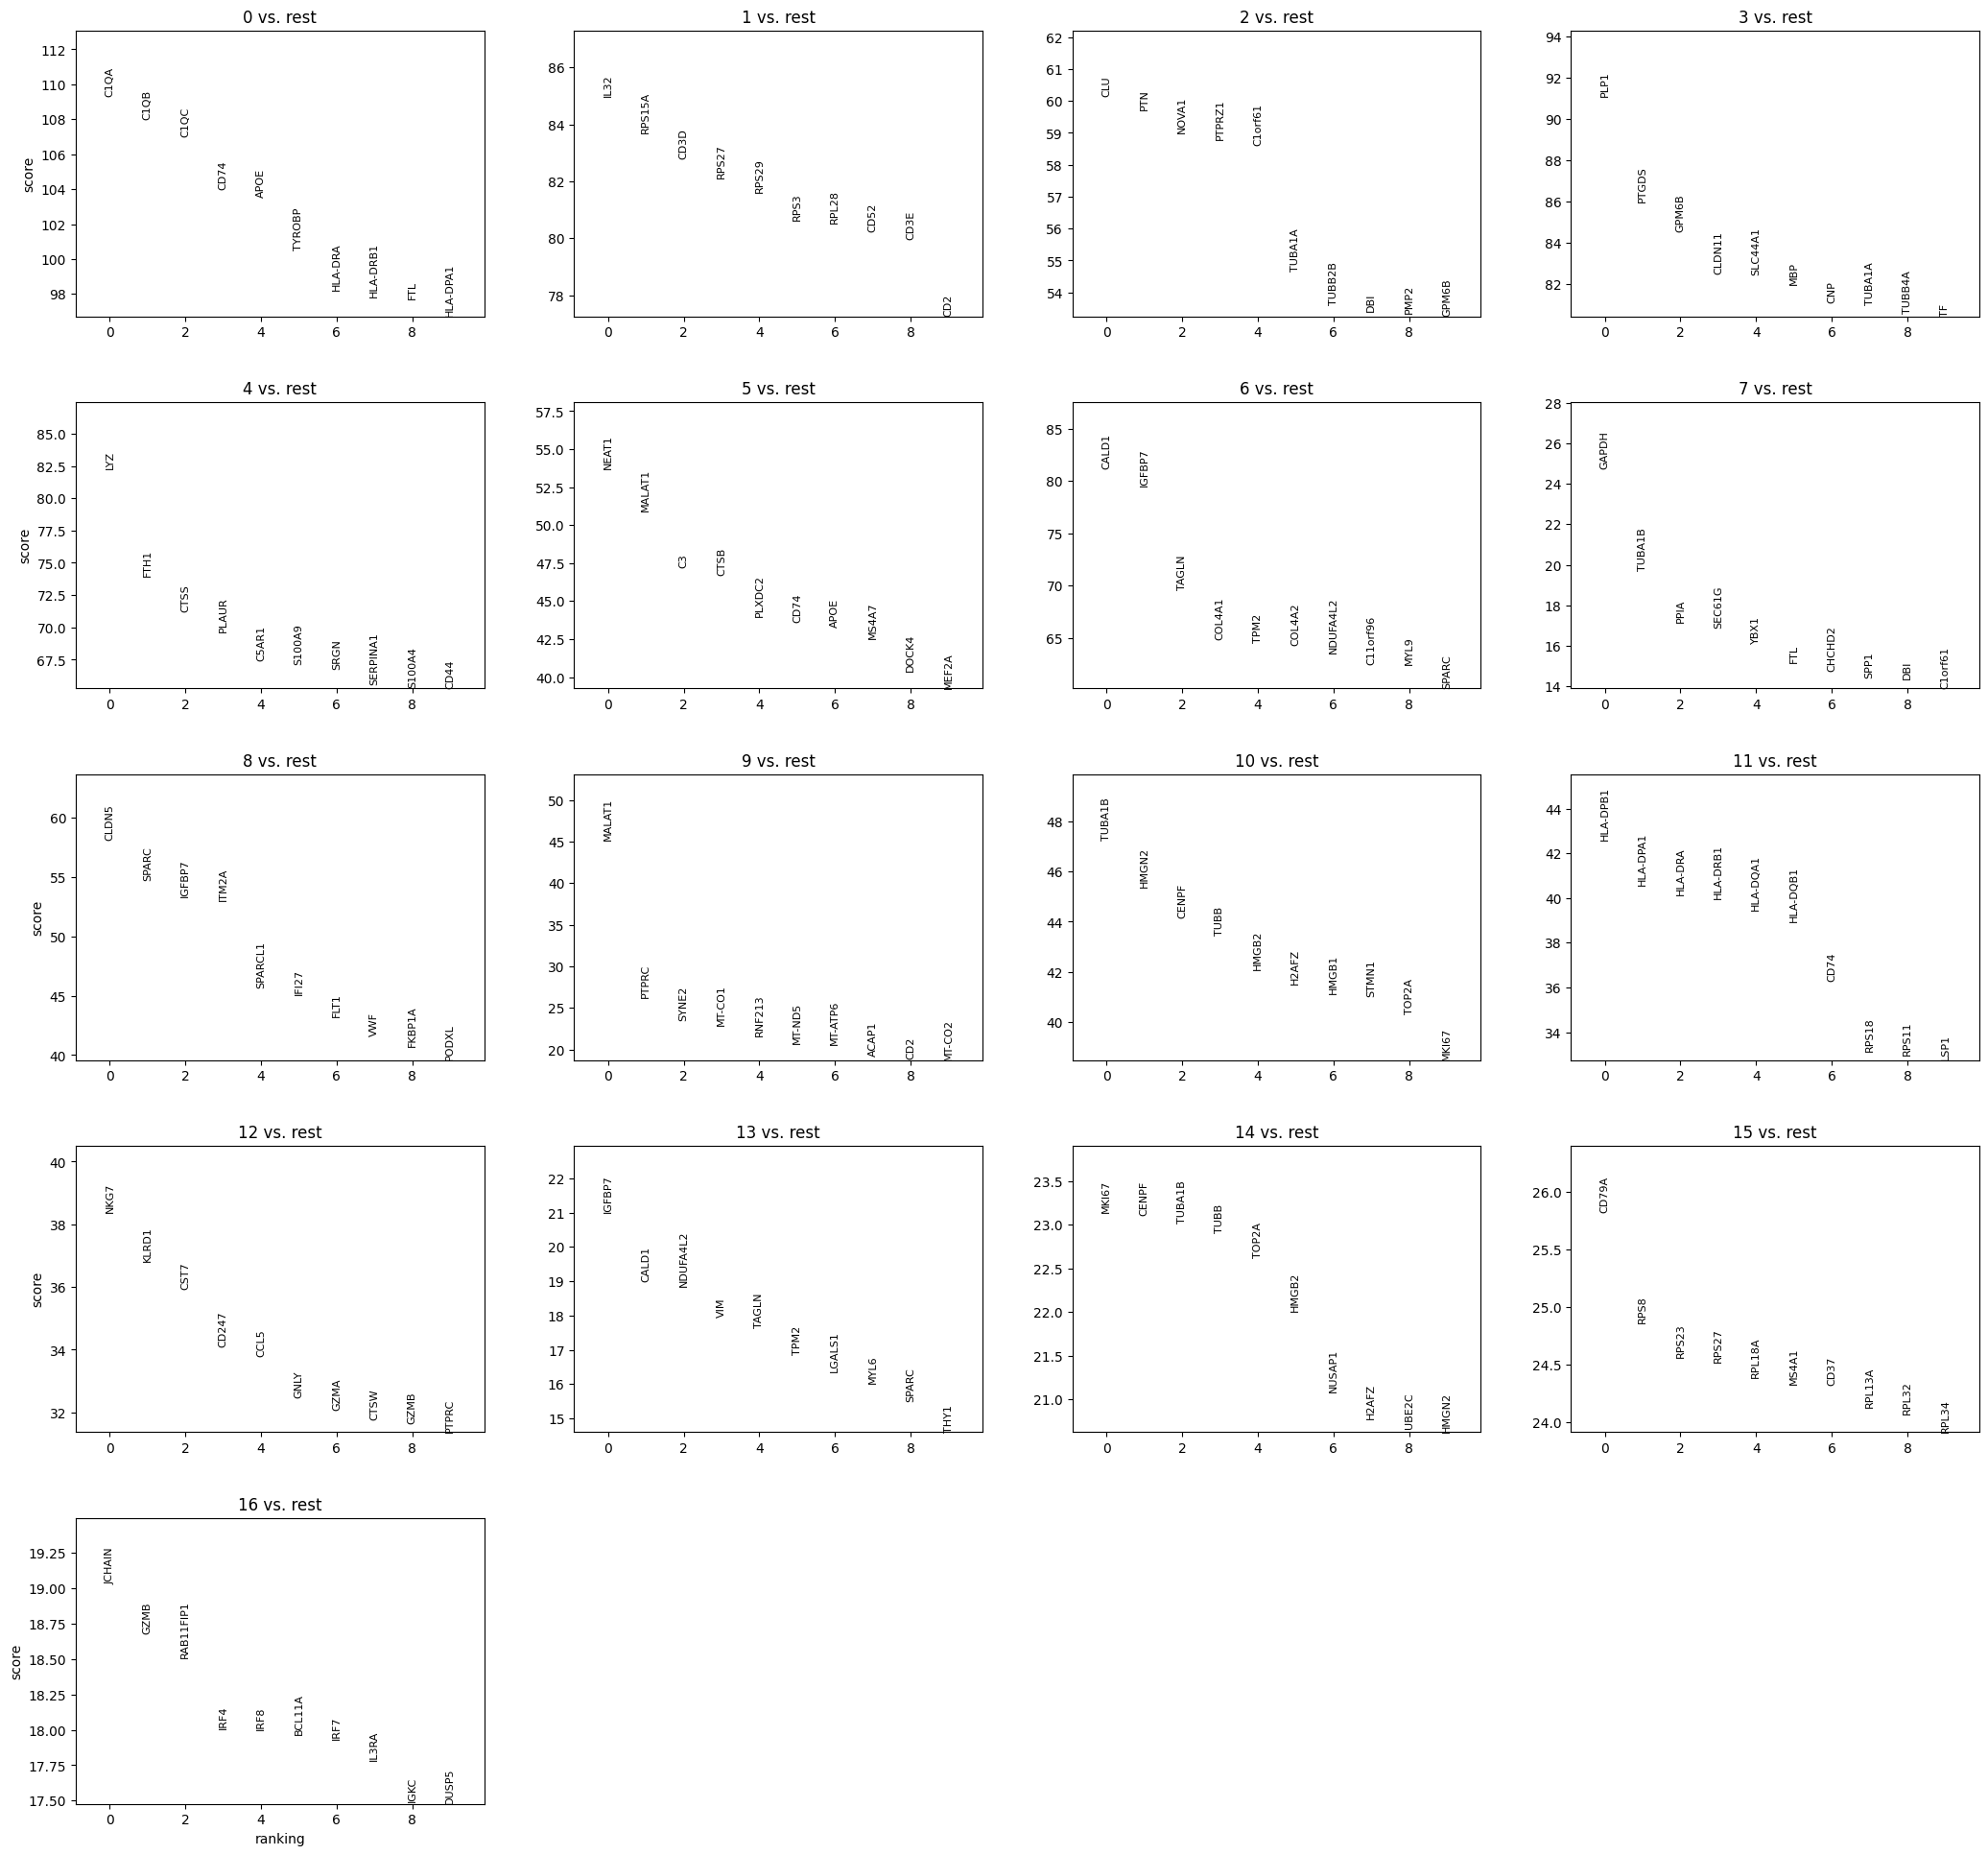

 Marker table saved. We can now continue with annotation.


In [ ]:
#import scanpy as sc
#import gc

# 1. Replace X with raw counts (necessary for Wilcoxon)
# We use .layers['raw_counts'] that we saved earlier, which contains the original counts before normalization
adata.X = adata.layers['raw_counts'].copy()   # Doing adata.X = adata..., we empty the main "compartment" and fill it again with the original (raw)
#data to be able to normalize it properly from scratch. 

# 2. Normalize and log (WITHOUT scaling)
# This transforms adata.X into the log-normalized matrix needed for Wilcoxon
sc.pp.normalize_total(adata, target_sum=1e4)        #Why we are using adata here instead of adata.X? 
sc.pp.log1p(adata)

# 3. Run the marker test for annotation
print("Calculating marker genes per cluster...")
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon', key_added='markers_leiden')

# 4. Save the result in a DataFrame and free the memory of adata.X immediately
# We extract the top 20 genes so you can view them without keeping the heavy object open
markers_df = sc.get.rank_genes_groups_df(adata, group=None, key='markers_leiden')
markers_df = markers_df[markers_df['logfoldchanges'] > 1].groupby('group').head(20)  # Keep only top 20 markers per cluster with logFC > 1

# Save the table to CSV so you can consult it outside of Python
markers_df.to_csv(ckpt_dir / 'top20_markers_per_cluster.csv', index=False)

# 5. Quick visualization of the top genes
sc.pl.rank_genes_groups(adata, key='markers_leiden', n_genes=10, sharey=False)

print(" Marker table saved. We can now continue with annotation.")


   - <span style="color:teal; font-size:14px">**Load the top 20 markers per cluster csv file that we saved in the previous step. This file contains the most significant marker genes for each cluster, which will help us identify the cell types.**</span>

In [24]:
#load csv file with top 20 markers per cluster
top20_markers_df=pd.read_csv(ckpt_dir / 'top20_markers_per_cluster.csv')

In [42]:
top20_markers_df

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,C1QA,109.303490,3.666513,0.000000e+00,0.000000e+00
1,0,C1QB,107.969890,3.614032,0.000000e+00,0.000000e+00
2,0,C1QC,107.019420,3.636203,0.000000e+00,0.000000e+00
3,0,CD74,103.986465,3.046259,0.000000e+00,0.000000e+00
4,0,APOE,103.566590,3.537720,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...
335,16,TSPAN13,16.758307,5.223495,4.924574e-63,7.803910e-60
336,16,SLC20A1,16.700916,3.919949,1.290682e-62,1.925014e-59
337,16,SEL1L3,16.560350,4.758222,1.348074e-61,1.898912e-58
338,16,SLC15A4,16.496277,4.646915,3.902227e-61,5.207419e-58


In [45]:
top20_markers_df['names'].nunique()

272

In [48]:
top20_markers_df.groupby('group')[['names']].apply(lambda x : print(x['names'].tolist())).nunique()

['C1QA', 'C1QB', 'C1QC', 'CD74', 'APOE', 'TYROBP', 'HLA-DRA', 'HLA-DRB1', 'FTL', 'HLA-DPA1', 'GPX1', 'TREM2', 'APOC1', 'NPC2', 'C3', 'AIF1', 'MS4A7', 'HLA-DMA', 'FCGR3A', 'RNASET2']
['IL32', 'RPS15A', 'CD3D', 'RPS27', 'RPS29', 'RPS3', 'RPL28', 'CD52', 'CD3E', 'CD2', 'RPL30', 'CD3G', 'RPS12', 'TRAC', 'RPL41', 'RPL23A', 'TRBC2', 'PTPRC', 'CCL5', 'RPS27A']
['CLU', 'PTN', 'NOVA1', 'PTPRZ1', 'C1orf61', 'TUBA1A', 'TUBB2B', 'DBI', 'PMP2', 'GPM6B', 'SOX2', 'MT3', 'IGFBP2', 'MAP1B', 'GPM6A', 'GAP43', 'METRN', 'MEG3', 'GAPDH', 'MARCKSL1']
['PLP1', 'PTGDS', 'GPM6B', 'CLDN11', 'SLC44A1', 'MBP', 'CNP', 'TUBA1A', 'TUBB4A', 'TF', 'RTN4', 'APLP1', 'MAG', 'CRYAB', 'MARCKSL1', 'UGT8', 'TSC22D4', 'MOG', 'S100B', 'ATP1B1']
['LYZ', 'FTH1', 'CTSS', 'PLAUR', 'C5AR1', 'S100A9', 'SRGN', 'SERPINA1', 'S100A4', 'CD44', 'NAMPT', 'SOD2', 'EREG', 'CEBPB', 'NCF2', 'CSTA', 'BCL2A1', 'S100A6', 'S100A8', 'VCAN']
['NEAT1', 'C3', 'CTSB', 'PLXDC2', 'CD74', 'APOE', 'MS4A7', 'DOCK4', 'MEF2A', 'CSF1R', 'PSAP', 'CD83', 'ADAM28

Series([], dtype: float64)

In [54]:
sc.tl.dendrogram(adata, groupby='leiden')


    using 'X_pca' with n_pcs = 50


Storing dendrogram info using `.uns['dendrogram_leiden']`


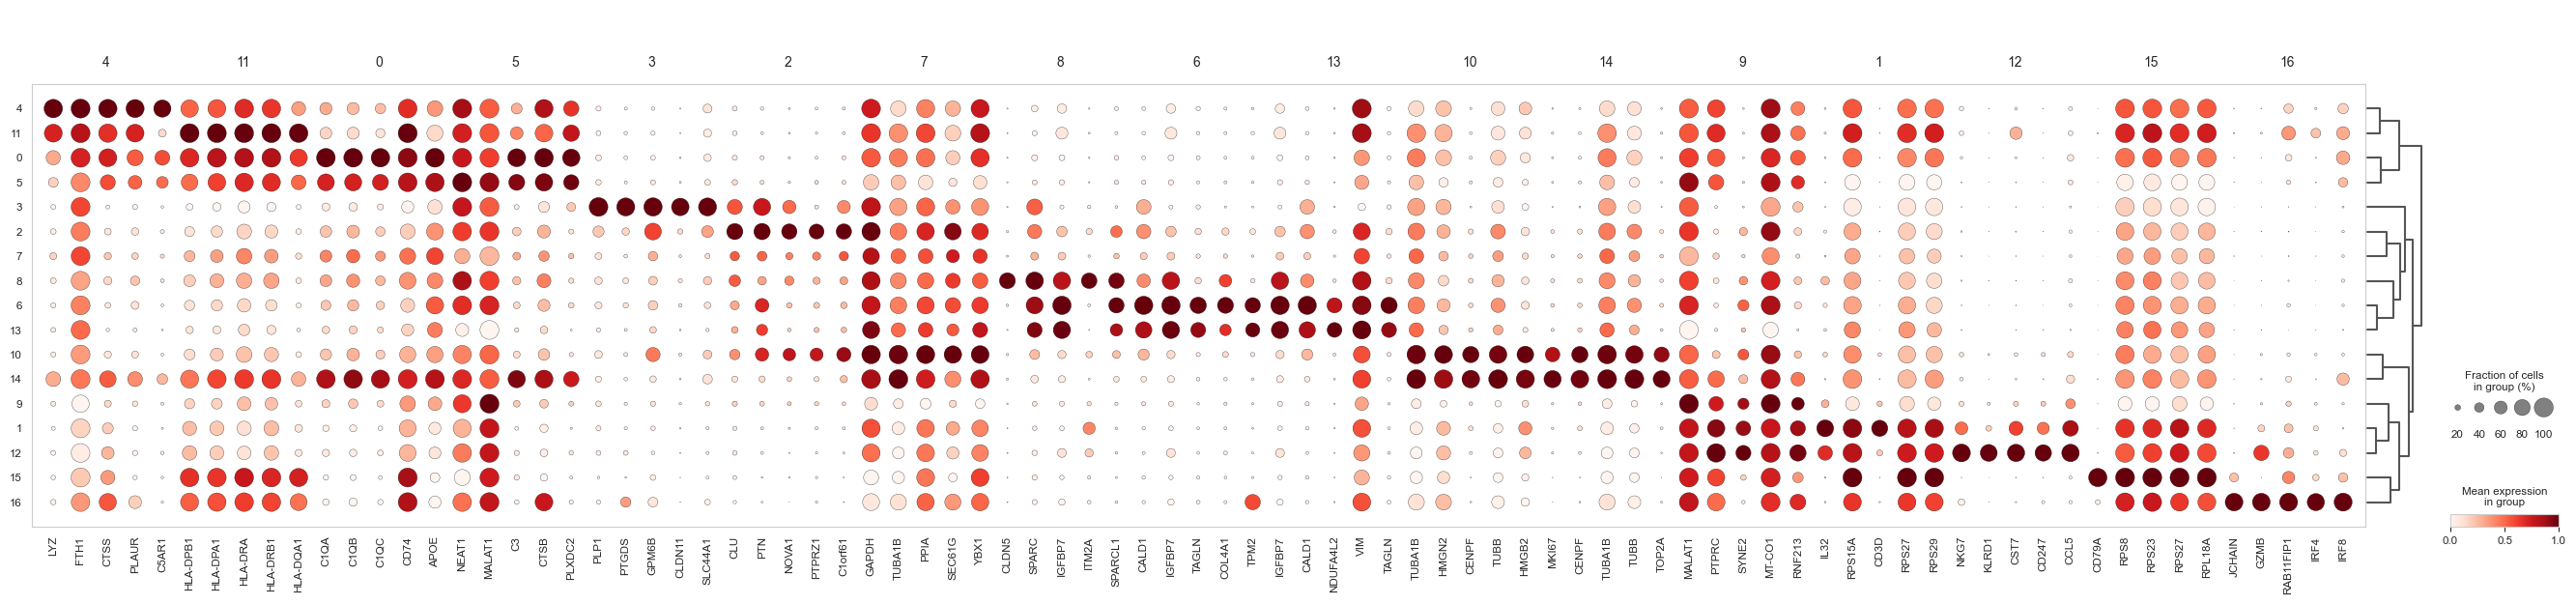

In [91]:
sc.pl.rank_genes_groups_dotplot(adata,
                                key='markers_leiden', 
                                n_genes=5, 
                                standard_scale='var',
                                groupby='leiden')


<span style="font-size:16px; color:orange">**As you can see on the dotplot, some genes are highly expressed in multiple clusters. We can filter the differentially expressed genes to select for more cluster-specific differentially expressed genes. In our case, we will focus on the top 3 markers per cluster with a log fold change greater than 1.**</span> 

In [92]:
top20_markers_df[top20_markers_df['logfoldchanges'] > 1].groupby('group').head(3)

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,C1QA,109.303490,3.666513,0.000000e+00,0.000000e+00
1,0,C1QB,107.969890,3.614032,0.000000e+00,0.000000e+00
2,0,C1QC,107.019420,3.636203,0.000000e+00,0.000000e+00
20,1,IL32,84.983280,5.736871,0.000000e+00,0.000000e+00
21,1,RPS15A,83.719940,2.030075,0.000000e+00,0.000000e+00
22,1,CD3D,82.788180,6.727093,0.000000e+00,0.000000e+00
40,2,CLU,60.142212,3.437324,0.000000e+00,0.000000e+00
41,2,PTN,59.736650,3.218131,0.000000e+00,0.000000e+00
42,2,NOVA1,58.988297,3.445445,0.000000e+00,0.000000e+00
60,3,PLP1,91.080150,8.246985,0.000000e+00,0.000000e+00


<span style="color:teal; font-size:16px">**Now let's create a clustermap to visualize the expression of these top markers across clusters. This will help us see which genes are driving the differences between clusters and assist in annotation.**</span>

In [ ]:
top20_markers_df.groupby('group')['names'].apply(lambda x : x[:3].tolist())

NameError: name 'top20_markers_df' is not defined

<span style="color:gold; font-size:13px">ESCALA DE COLORS en el clustermap: La escala de colors "Greens" és adequada per mostrar canvis positius en l'expressió gènica, ja que els tons més clars indiquen una expressió més baixa i els tons més foscos indiquen una expressió més alta. Això facilita la identificació de patrons d'expressió específics per a cada cluster, ajudant a diferenciar-los visualment.(Suggerencia JOAN)

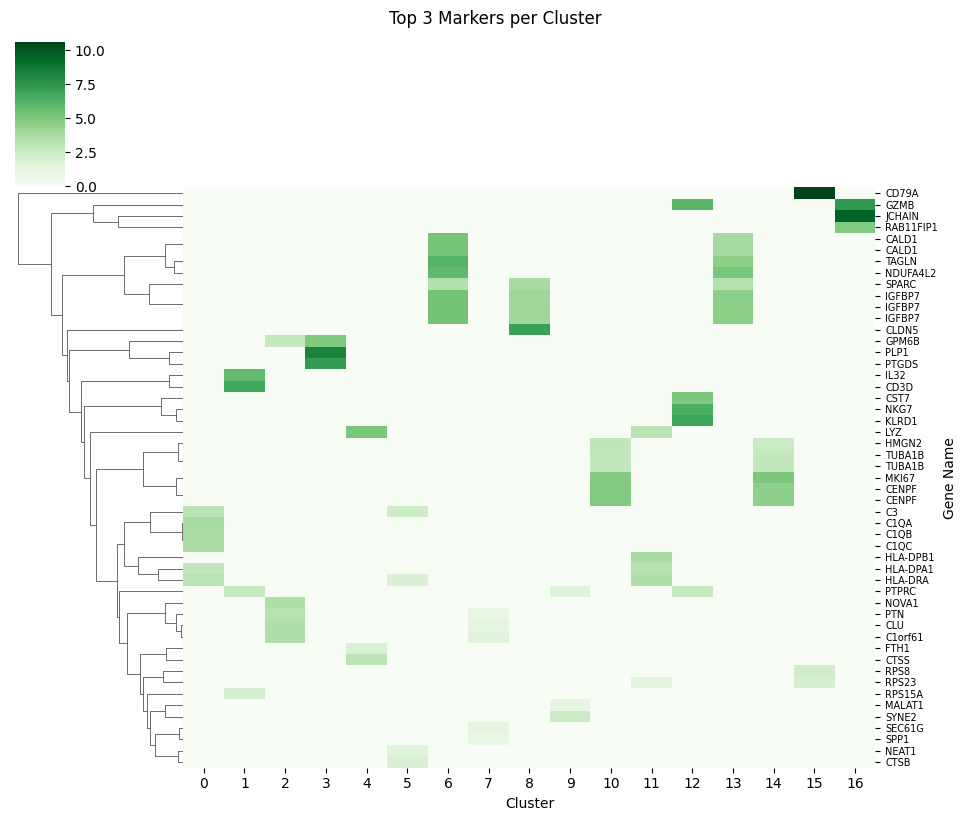

In [ ]:
""""
import seaborn as sns
import matplotlib.pyplot as plt
"""

#top20_markers_df=pd.read_csv(ckpt_dir / 'top20_markers_per_cluster.csv')
# 1. We reshape the data into a matrix (Genes x Clusters)
# This moves 'names' to rows and 'group' to columns
pivot_df = top20_markers_df.pivot(index='names', columns='group', values='logfoldchanges').fillna(0)

# 2. Create the clustermap
# Note: clustermap creates its own figure, so don't call plt.figure() beforehand
g = sns.clustermap(
    pivot_df.loc[top20_markers_df.groupby('group')['names'].apply(lambda x: x[:3]).explode()],  # Keep only top 3 markers per cluster
    z_score=None,           # Use None if logfoldchanges are already normalized
    cmap="Greens",          # Good for showing positive/negative fold changes
    figsize=(10, 8),
    row_cluster=True,       # Clusters genes with similar expression patterns
    col_cluster=False,       # Clusters similar cell groups
    xticklabels=True,
    yticklabels=True        # Set to False if you have hundreds of genes
)
g.ax_heatmap.tick_params(axis='y', labelsize=7)  # Rotate x-axis labels for better readability

# 3. Add titles (Clustermap uses 'g.fig' for the overall figure)
g.fig.suptitle('Top 3 Markers per Cluster', y=1.02)
g.ax_heatmap.set_xlabel('Cluster')
g.ax_heatmap.set_ylabel('Gene Name')

plt.show()


<span style="font-size:14px"><span style="color:red">**Comment**:</span> Observing the clustermap, we can see that clusters are well separated based on their gene expression profiles, which supports the robustness of our clustering and the biological relevance of the identified clusters. The top marker genes for each cluster show distinct expression patterns that can be used to annotate the clusters with specific cell types or states.</span>

<span style="color:gold; font-size:14px">This heatmap summarizes the top three marker genes for each cluster and confirms the presence of distinct cellular compartments within the GBM microenvironment. Clusters are clearly separated according to their characteristic gene expression profiles, supporting robust biological annotation after quality control and integration.<br><br>
The myeloid compartment is represented by clusters enriched in complement and inflammatory genes such as C1QC, C1QA, C3, CTSB, and HLA-DRA/B1, consistent with macrophages, microglia, and antigen-presenting cells. Lymphoid populations are identified through canonical immune markers including CD3D (T cells), NKG7/KLRD1 (NK or cytotoxic cells), and JCHAIN/CD79A (B and plasma cells).<br><br>
Several clusters correspond to malignant glioblastoma states, reflecting the known transcriptional plasticity of GBM. Astrocyte-like tumor populations express CLU and PTN, OPC-like states express PLP1 and GPM6B, while mesenchymal-like tumor cells show SPP1 expression, a marker associated with aggressive behavior. Proliferative tumor clusters are characterized by strong MKI67, CENPF, and UBE2C expression, indicating active cell cycling.<br><br>
The vascular compartment is also well defined, with endothelial and pericyte-like populations expressing CLDN5, IGFBP7, CALD1, and TAGLN, highlighting active angiogenesis and vascular remodeling within the tumor microenvironment. Overall, the heatmap demonstrates a biologically coherent clustering structure with clear separation between immune, tumor, and vascular cell populations.</span>

<span style="font-size:14px">**We will perform a last check of the top 3 markers per cluster through a dotplot to visualize their expression across clusters. This will help us confirm that these markers are indeed specific to their respective clusters and can be used for annotation.**</span>

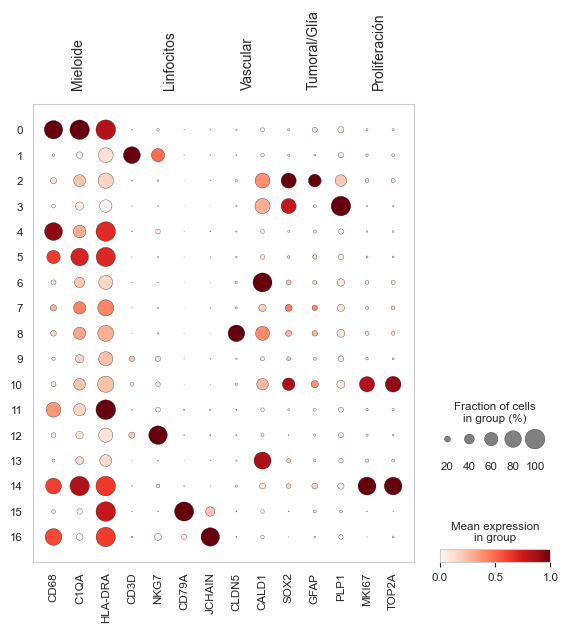

In [ ]:
# Key markers for annotation based on the literature and the top markers we found in our data.
markers_check = {
    'Myeloide': ['CD68', 'C1QA', 'HLA-DRA'],
    'Lymphocytes': ['CD3D', 'NKG7', 'CD79A', 'JCHAIN'],
    'Vascular': ['CLDN5', 'CALD1'],
    'Tumoral/Glia': ['SOX2', 'GFAP', 'PLP1'],
    'Proliferation': ['MKI67', 'TOP2A']
}

sc.pl.dotplot(adata, markers_check,
              groupby='leiden',
              standard_scale='var')

<span style="color:gold; font-size:14px">After reviewing the dotplot, we observe that most clusters display clean and lineage-specific marker expression, supporting the robustness of the annotation and clustering strategy.<br><br>
**Cluster 12** represents a particularly clean immune population, characterized almost exclusively by strong NKG7 expression, consistent with NK cells or cytotoxic T lymphocytes. In contrast, <span style="color:red">**Cluster 9**</span> remains poorly defined, showing very limited expression across the selected marker panel. This “ghost-like” cluster may correspond to low-RNA cells, residual neuronal populations, ***or a rare cell type not fully captured by the current marker set***.<br><br>
A notable finding is <span style="color:green">**Cluster 14**</span>, which ***simultaneously expresses proliferation markers such as MKI67 and TOP2A together with myeloid markers including CD68 and C1QA. This suggests the presence of proliferative macrophages or a mixed proliferative myeloid population, a phenomenon that has been previously associated with aggressive and immunosuppressive states in glioblastoma***.<br><br>
Overall, the DotPlot confirms the coexistence of distinct immune, vascular, and malignant compartments while also revealing transitional or functionally specialized populations that may have biological relevance in GBM progression and recurrence.</span>



### REVIEW###
Based on these top 20 genes, Cluster 14 is a pure Proliferation / Cell Cycle cluster.All 20 genes are classic hallmarks of the G2/M and S phases:MKI67 (Ki-67) & TOP2A: Standard clinical markers for active cell division.CENPF & ASPM: Centromere proteins involved in chromosome segregation.CDK1 & UBE2C: Master regulators of the cell cycle.TUBA1B & TUBB: Tubulins, essential for forming the mitotic spindle during mitosis.Why did we see some "Mieloide" signal in the DotPlot earlier?In Glioblastoma, it is common to see a small amount of "lineage leakage" in the proliferation cluster. Because these cells are tumor cells or macrophages that are dividing, they might retain a low-level signature of their origin. However, their primary identity at this stage is defined by the fact that they are replicating. This is a known phenomenon in single-cell analysis of tumors, where proliferative states can sometimes show mixed lineage signals due to the plasticity of cancer cells and their ability to co-opt various transcriptional programs. Therefore, while Cluster 14 is primarily a proliferation cluster, the presence of some myeloid markers does not necessarily contradict its annotation but rather reflects the complex biology of GBM.

   - <span style="color:olive; font-size:16px">**ANNOTATION**</span>

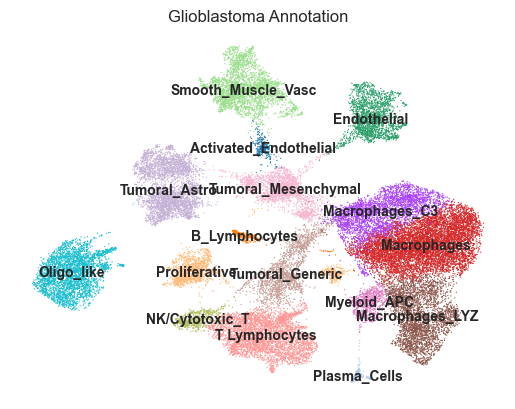

Annotation completed and object saved.


In [ ]:
# Final annotation dictionary based on visualizations and literature review
annotation_dict = {
    '0': 'Macrophages', 
    '1': 'T Lymphocytes', 
    '2': 'Tumoral_Astro',
    '3': 'Oligo_like', 
    '4': 'Macrophages_LYZ', 
    '5': 'Macrophages_C3',
    '6': 'Smooth_Muscle_Vasc', 
    '7': 'Tumoral_Mesenchymal', 
    '8': 'Endothelial',
    '9': 'Tumoral_Generic', 
    '10': 'Proliferative', 
    '11': 'Myeloid_APC',
    '12': 'NK/Cytotoxic_T', 
    '13': 'Activated_Endothelial', 
    '14': 'Proliferative',
    '15': 'B_Lymphocytes', 
    '16': 'Plasma_Cells'
}

# Apply to the object to create a new column 'cell_type' in adata.obs with the annotated cell types
adata.obs['cell_type'] = adata.obs['leiden'].map(annotation_dict)

# Save the annotated anndata. 
adata.write_h5ad(ckpt_dir / 'part5_annotated_adata.h5ad')

# UMAP visualization of the annotated cell types
sc.pl.umap(adata, color='cell_type', legend_loc='on data', 
           frameon=False, title='Glioblastoma Annotation',
           save='_UMAP_annotated.pdf')

print("Annotation completed and object saved.")


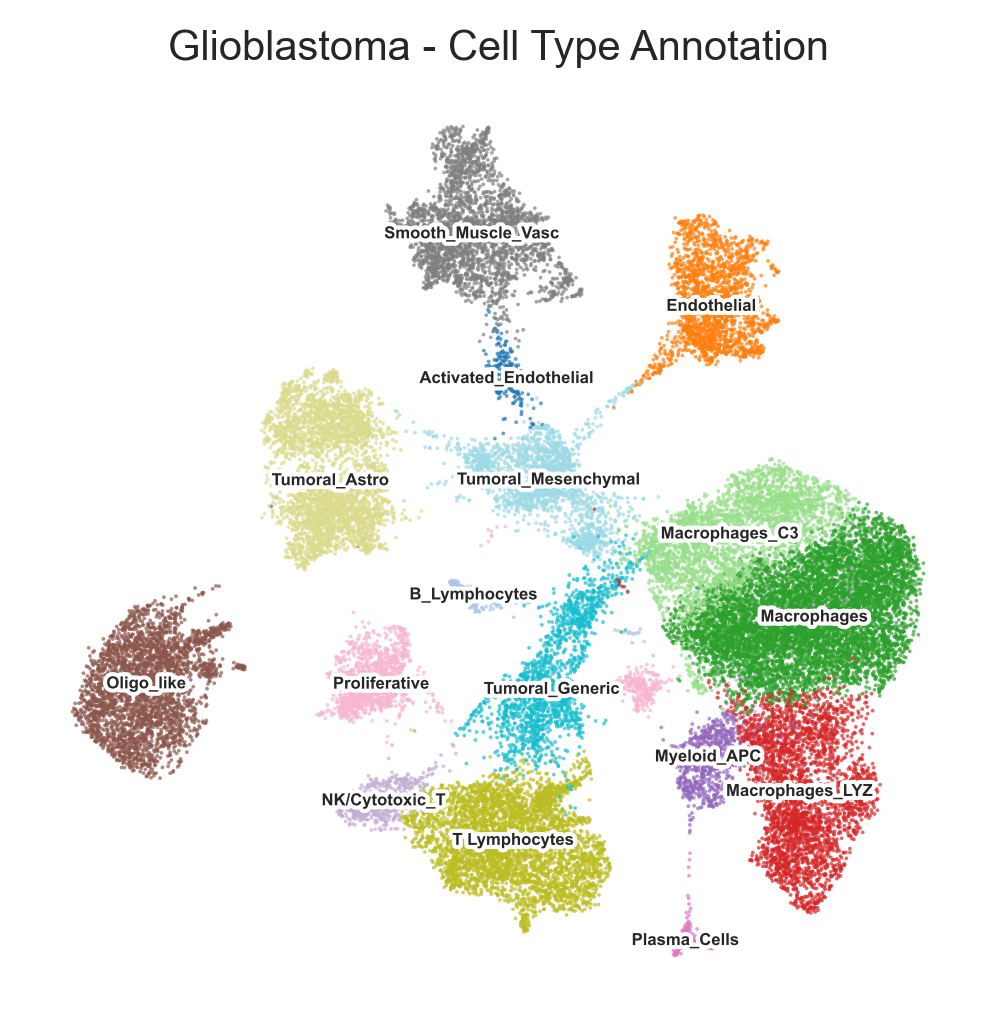

In [116]:
# Ajustamos parámetros estéticos globales de Scanpy
sc.set_figure_params(dpi=150, frameon=False, vector_friendly=True, fontsize=10)

sc.pl.umap(
    adata, 
    color='cell_type', 
    legend_loc='on data', # Movamos la leyenda fuera para limpiar el centro
    legend_fontsize=4,
    legend_fontoutline=2,    # Puntos más pequeños para reducir el "ruido"
    alpha=0.7,                 # Un poco de transparencia ayuda a ver la densidad
    title='Glioblastoma - Cell Type Annotation'
)



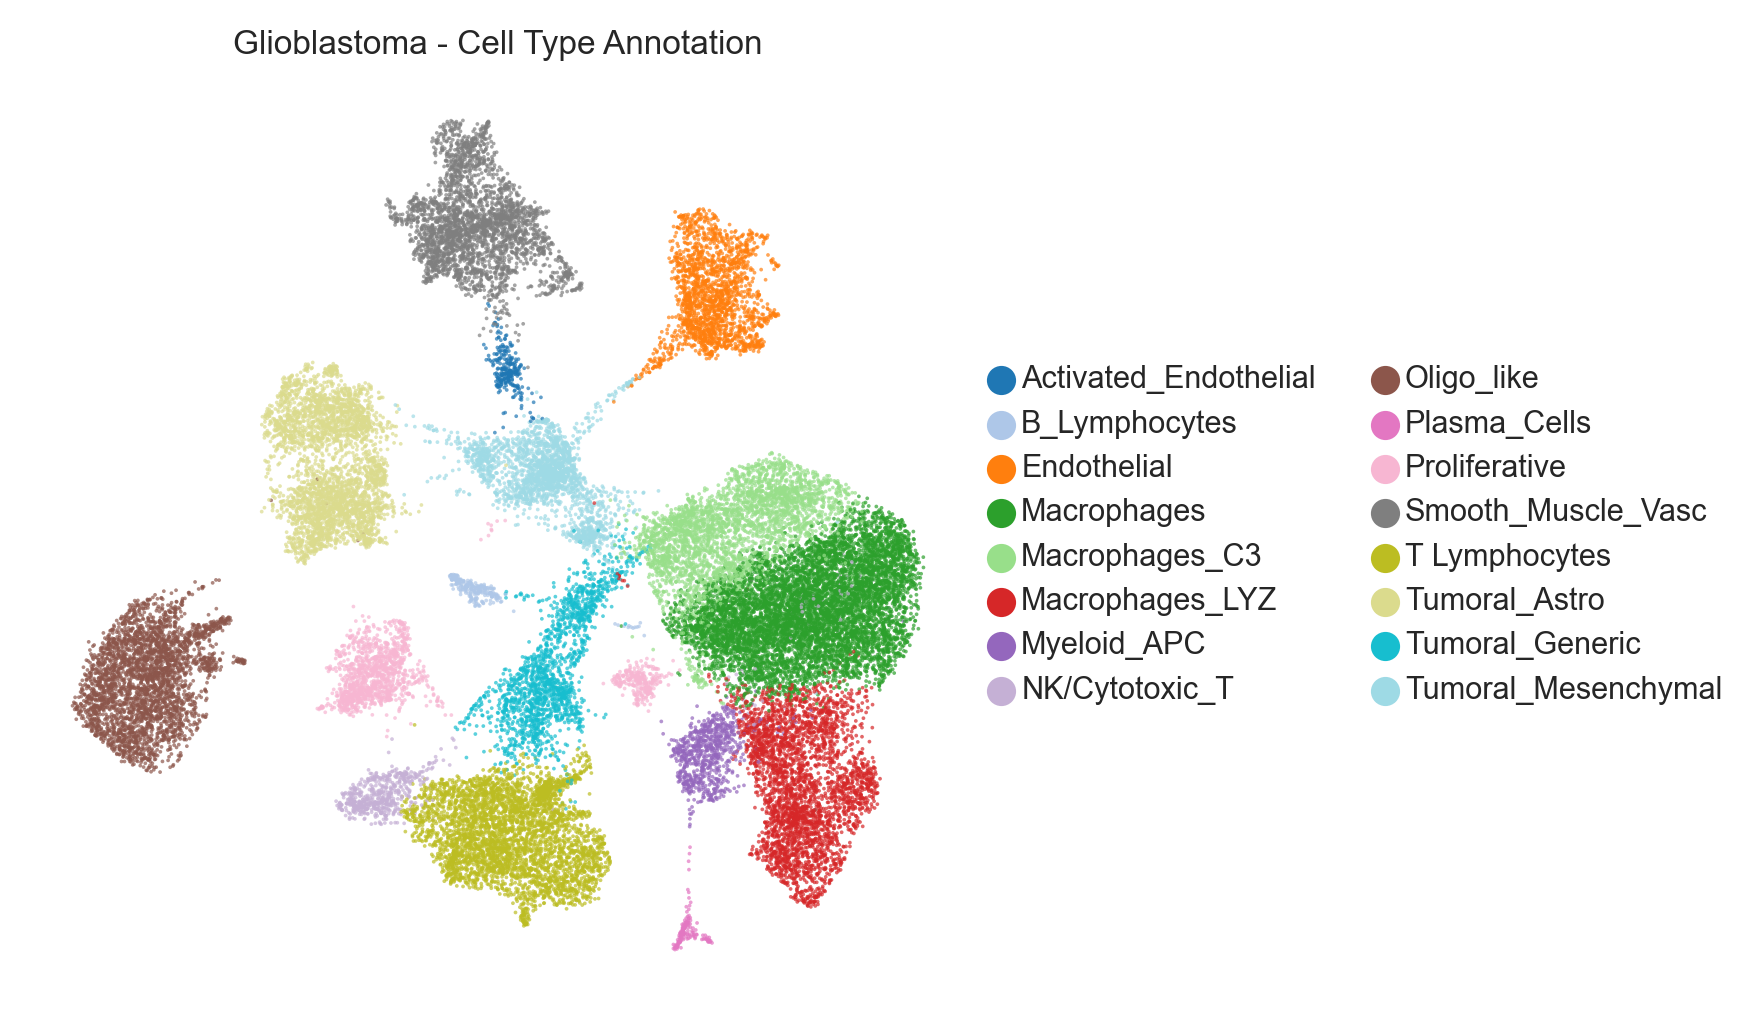

In [120]:
sc.set_figure_params(dpi=150, frameon=False, vector_friendly=True, fontsize=8)

sc.pl.umap(
    adata, 
    color='cell_type', 
    alpha=0.7,                 # Un poco de transparencia ayuda a ver la densidad
    title='Glioblastoma - Cell Type Annotation',
    save='UMAP_per_anotarJO.pdf'
)

In [121]:
del adata; gc.collect()

193128

In [117]:
check_ram()

RAM in use: 1.5 GB


<span style="color:olive; font-size:22px">**Compositional analysis**</span>

<span style="font-size:14px">Compositional analysis is a crucial step in understanding the differences in cell type distributions between conditions. By comparing the proportions of different cell types or clusters across conditions, we can gain insights into how the tumor microenvironment changes in response to treatment or disease progression.</span>

In [123]:
print(adata.obs['condition'].value_counts())
print(adata.obs['condition'].unique())

condition
ND     24965
Rec    12018
Name: count, dtype: int64
['ND', 'Rec']
Categories (2, object): ['ND', 'Rec']


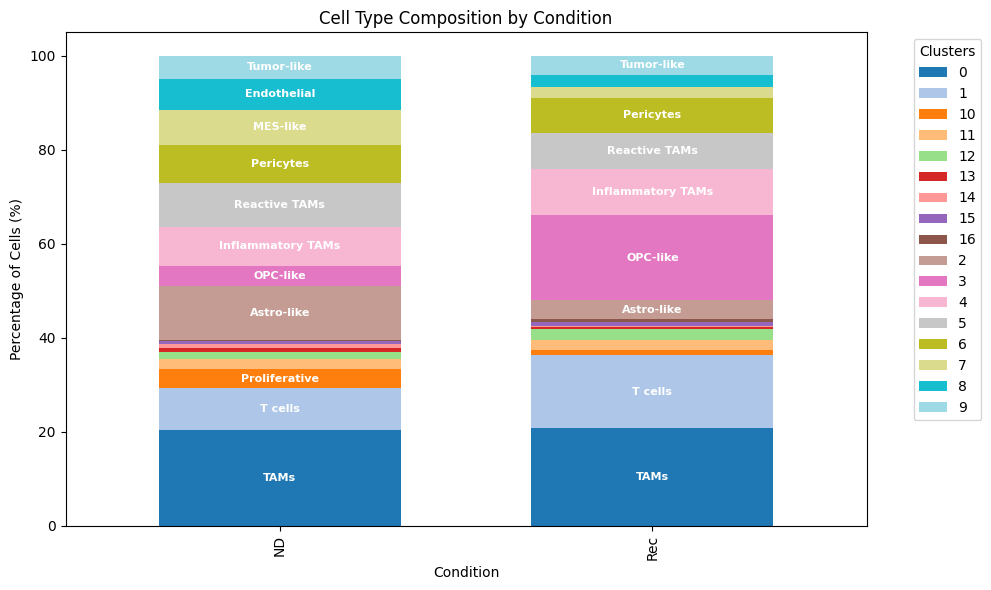

--- Proportion on Newly Diagnosed (%) ---
condition  Percentage
leiden               
0           20.396555
2           11.452033
5            9.345083
1            8.828360
4            8.251552


--- Proportion on Recurrent (%) ---
condition  Percentage
leiden               
0           20.785488
3           18.006324
1           15.435181
4            9.910135
5            7.596938


In [ ]:
"""
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
"""
adata=sc.read_h5ad(ckpt_dir / 'part5_annotated_adata_v2.h5ad')


# Crosstab in %
composition = pd.crosstab(
    adata.obs['leiden'].astype(str),
    adata.obs['condition'].astype(str),
    normalize='columns'
) * 100

# DataFrame for condition
df_denovo = composition[['ND']].copy().rename(columns={'ND': 'Percentage'})
df_recurrent = composition[['Rec']].copy().rename(columns={'Rec': 'Percentage'})

# Cluster -> cell type name
cluster_names = {

    # Myeloid compartment
    '0': 'TAMs',
    '4': 'Inflammatory TAMs',
    '5': 'Reactive TAMs',
    '11': 'Myeloid APCs',
    '14': 'Cycling',

    # Lymphoid compartment
    '1': 'T cells',
    '12': 'NK/Cytotoxic',
    '15': 'B cells',
    '16': 'Plasma cells',

    # Tumor compartment
    '2': 'Astro-like',
    '3': 'OPC-like',
    '7': 'MES-like',
    '9': 'Tumor-like',
    '10': 'Proliferative',

    # Vascular compartment
    '6': 'Pericytes',
    '8': 'Endothelial',
    '13': 'Activated Endothelial'
}

# Plot
ax = composition.T.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='tab20',
    width=0.65
)

# Add labels inside each segment
for i, cond in enumerate(composition.columns):
    bottom = 0
    for cl in composition.index:
        val = composition.loc[cl, cond]
        if val >= 4:  # label only if big enough
            ax.text(
                i,
                bottom + val / 2,
                cluster_names.get(str(cl), str(cl)),
                ha='center',
                va='center',
                fontsize=8,
                rotation=0,
                color='white',
                fontweight='bold'
            )
        bottom += val

ax.set_title('Cell Type Composition by Condition')
ax.set_ylabel('Percentage of Cells (%)')
ax.set_xlabel('Condition')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Clusters')
plt.tight_layout()
plt.savefig('Comp_named_stacked_bar.pdf', bbox_inches='tight')
plt.show()

# Show df tables
print("--- Proportion on Newly Diagnosed (%) ---")
print(df_denovo.sort_values('Percentage', ascending=False).head())
print()
print("\n--- Proportion on Recurrent (%) ---")
print(df_recurrent.sort_values('Percentage', ascending=False).head())

In [11]:
df_denovo.sort_values('Percentage', ascending=False)

condition,Percentage
leiden,
0,20.396555
2,11.452033
5,9.345083
1,8.828360
4,8.251552
6,8.083317
7,7.534548
8,6.569197
9,4.878830


In [7]:
df_recurrent.sort_values('Percentage', ascending=False)

condition,Percentage
leiden,
0,20.785488
3,18.006324
1,15.435181
4,9.910135
5,7.596938
6,7.505409
2,4.102180
9,4.052255
8,2.612748


<span style="color:olive; font-size:16px">We integrate the cell type annotation into the composition analysis to see how the distribution of cell types varies across conditions. This will help us understand if certain cell types are more prevalent in one condition compared to the other, which can provide insights into the biological differences between the conditions.</span>

In [8]:
# Crosstab in %
composition_celltype = pd.crosstab(
    index=[adata.obs['leiden'], adata.obs['cell_type']], 
    columns=adata.obs['condition'],
    normalize='columns'
) * 100

del adata; gc.collect()

26

In [9]:
composition_celltype

,condition,ND,Rec
leiden,cell_type,,
0,TAMs,20.396555,20.785488
1,T cells,8.828360,15.435181
2,Astro-like,11.452033,4.102180
3,OPC-like,4.281995,18.006324
4,Inflammatory TAMs,8.251552,9.910135
5,Reactive TAMs,9.345083,7.596938
6,Pericytes,8.083317,7.505409
7,MES-like,7.534548,2.279913
8,Endothelial,6.569197,2.612748


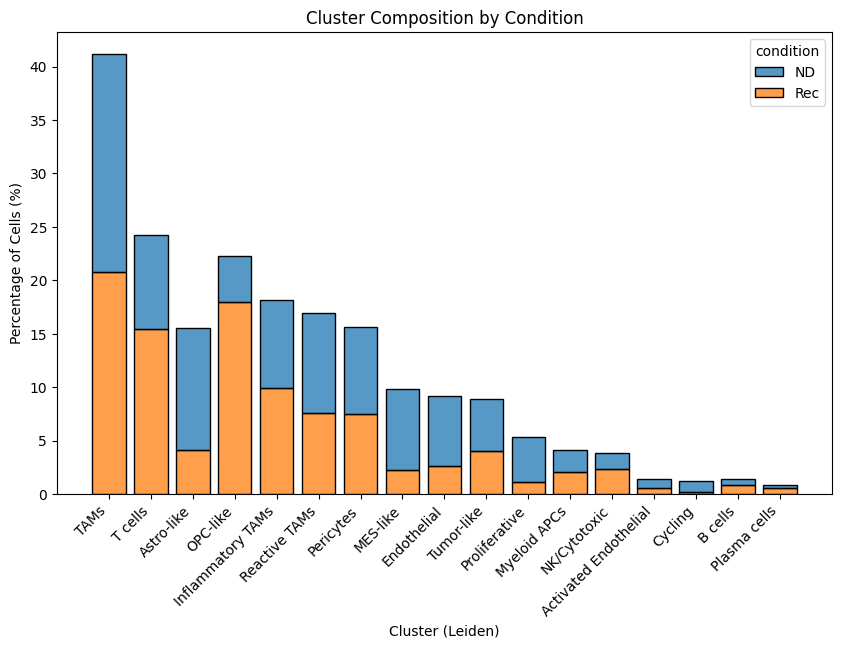

In [10]:
#import seaborn as sns
#import matplotlib.pyplot as plt

# 1. Melt the dataframe so it's compatible with Seaborn
# This turns columns (conditions) into a single column of labels
df_plot = composition_celltype.reset_index().melt(
    id_vars=['leiden', 'cell_type'], 
    var_name='condition', 
    value_name='percentage'
)

# 2. Create the plot
plt.figure(figsize=(10, 6))

# We use histplot or barplot. For a classic stacked look:
sns.histplot(
    data=df_plot,
    x='cell_type',
    weights='percentage',
    hue='condition',
    multiple='stack',
    shrink=0.8
)

plt.ylabel("Percentage of Cells (%)")
plt.xlabel("Cluster (Leiden)")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.title("Cluster Composition by Condition")
plt.show()


computing neighbors
    finished (0:00:10)
computing UMAP
    finished (0:00:26)


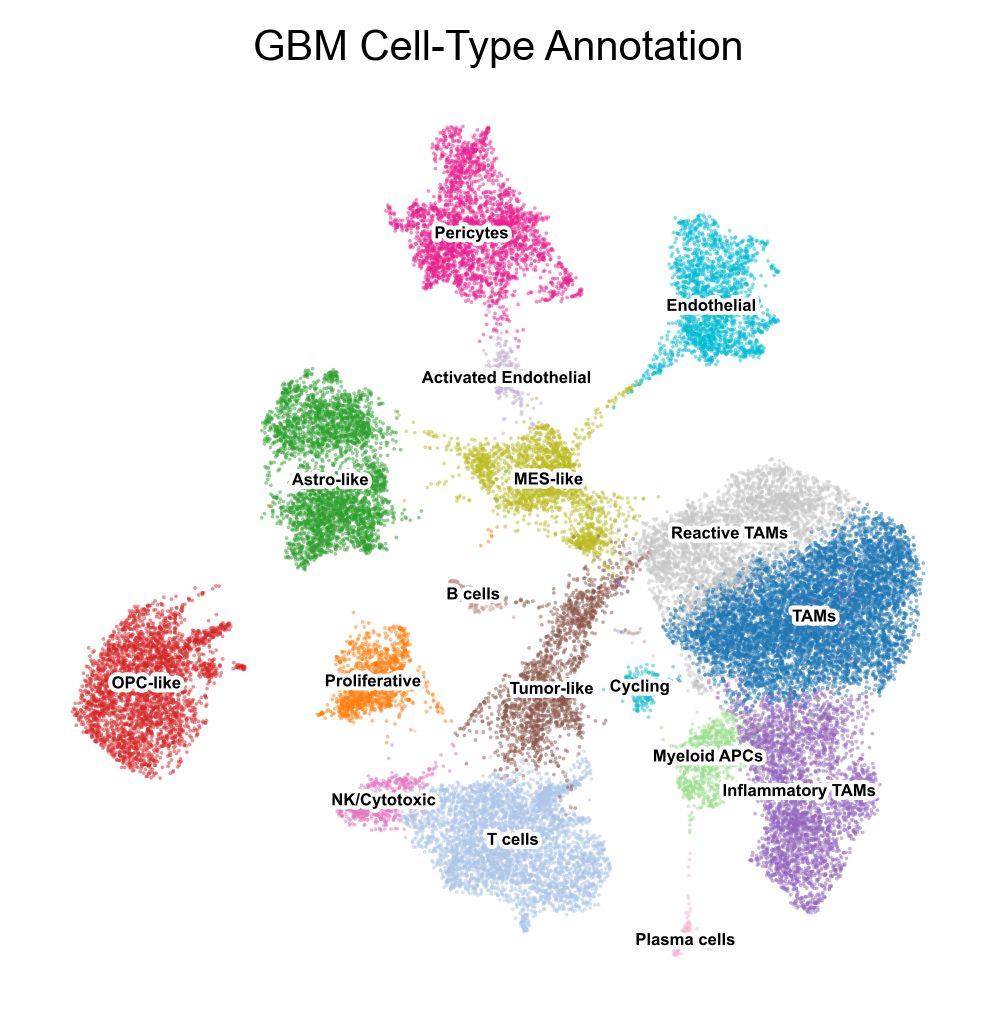

Annotation completed successfully.


NameError: name 'output_file' is not defined

In [ ]:
"""""
import scanpy as sc
from pathlib import Path

# =========================================================
# Load integrated and cleaned AnnData object
# =========================================================

adata = sc.read_h5ad(ckpt_dir / 'final_clean_adata.h5ad')

# =========================================================
# Recompute neighborhood graph and UMAP
# (recommended after filtering/doublet removal)
# =========================================================

sc.pp.neighbors(
    adata,
    use_rep='X_pca_harmony',
    n_neighbors=15,
    n_pcs=30
)

sc.tl.umap(adata)

# =========================================================
# Final cell-type annotations
# Based on marker genes, DotPlot and literature review
# =========================================================

annotation_dict = {

    # Myeloid compartment
    '0': 'TAMs',
    '4': 'Inflammatory TAMs',
    '5': 'Reactive TAMs',
    '11': 'Myeloid APCs',
    '14': 'Cycling',

    # Lymphoid compartment
    '1': 'T cells',
    '12': 'NK/Cytotoxic',
    '15': 'B cells',
    '16': 'Plasma cells',

    # Tumor compartment
    '2': 'Astro-like',
    '3': 'OPC-like',
    '7': 'MES-like',
    '9': 'Tumor-like',
    '10': 'Proliferative',

    # Vascular compartment
    '6': 'Pericytes',
    '8': 'Endothelial',
    '13': 'Activated Endothelial'
}

# Color palette matched from your UMAP figure
cell_type_colors = {
    'TAMs':                  '#1f77b4',  # steel blue
    'T cells':               '#aec7e8',  # light blue
    'Proliferative':         '#ff7f0e',  # orange
    'OPC-like':              '#d62728',  # red
    'Astro-like':            '#2ca02c',  # green
    'MES-like':              '#bcbd22',  # yellow-green/olive
    'Inflammatory TAMs':     '#9467bd',  # purple
    'Reactive TAMs':         '#c7c7c7',  # light grey
    'Myeloid APCs':          '#98df8a',  # light green
    'Cycling':               '#17becf',  # teal/cyan
    'Tumor-like':            '#8c564b',  # brown
    'NK/Cytotoxic':          '#e377c2',  # pink-magenta
    'B cells':               '#c49c94',  # light brown/mauve
    'Plasma cells':          '#f7b6d2',  # light pink
    'Endothelial':           '#00bcd4',  # bright cyan
    'Activated Endothelial': '#c5b0d5',  # light purple/lavender
    'Pericytes':             '#e91e8c',  # hot pink
}
# =========================================================
# Apply annotations
# =========================================================

adata.obs['cell_type'] = (
    adata.obs['leiden']
    .map(annotation_dict)
    .astype('category')
)

# =========================================================
# Save annotated object
# Use a NEW checkpoint to avoid accidental overwriting
# =========================================================

#output_file = ckpt_dir / 'part5_annotated_adata_v2.h5ad'

#adata.write_h5ad(output_file)

# =========================================================
# Annotated UMAP visualization
# =========================================================
sc.set_figure_params(dpi=150, frameon=False, vector_friendly=True, fontsize=10)
sc.pl.umap(
    adata,
    color='cell_type',
    legend_loc='on data',
    legend_fontsize=4,
    legend_fontoutline=2,
    alpha=0.5,
    frameon=False,
    title='GBM Cell-Type Annotation',
    palette=cell_type_colors
)

del adata; gc.collect()
print(f"Annotation completed successfully.")
print(f"Annotated object saved to: {output_file}")

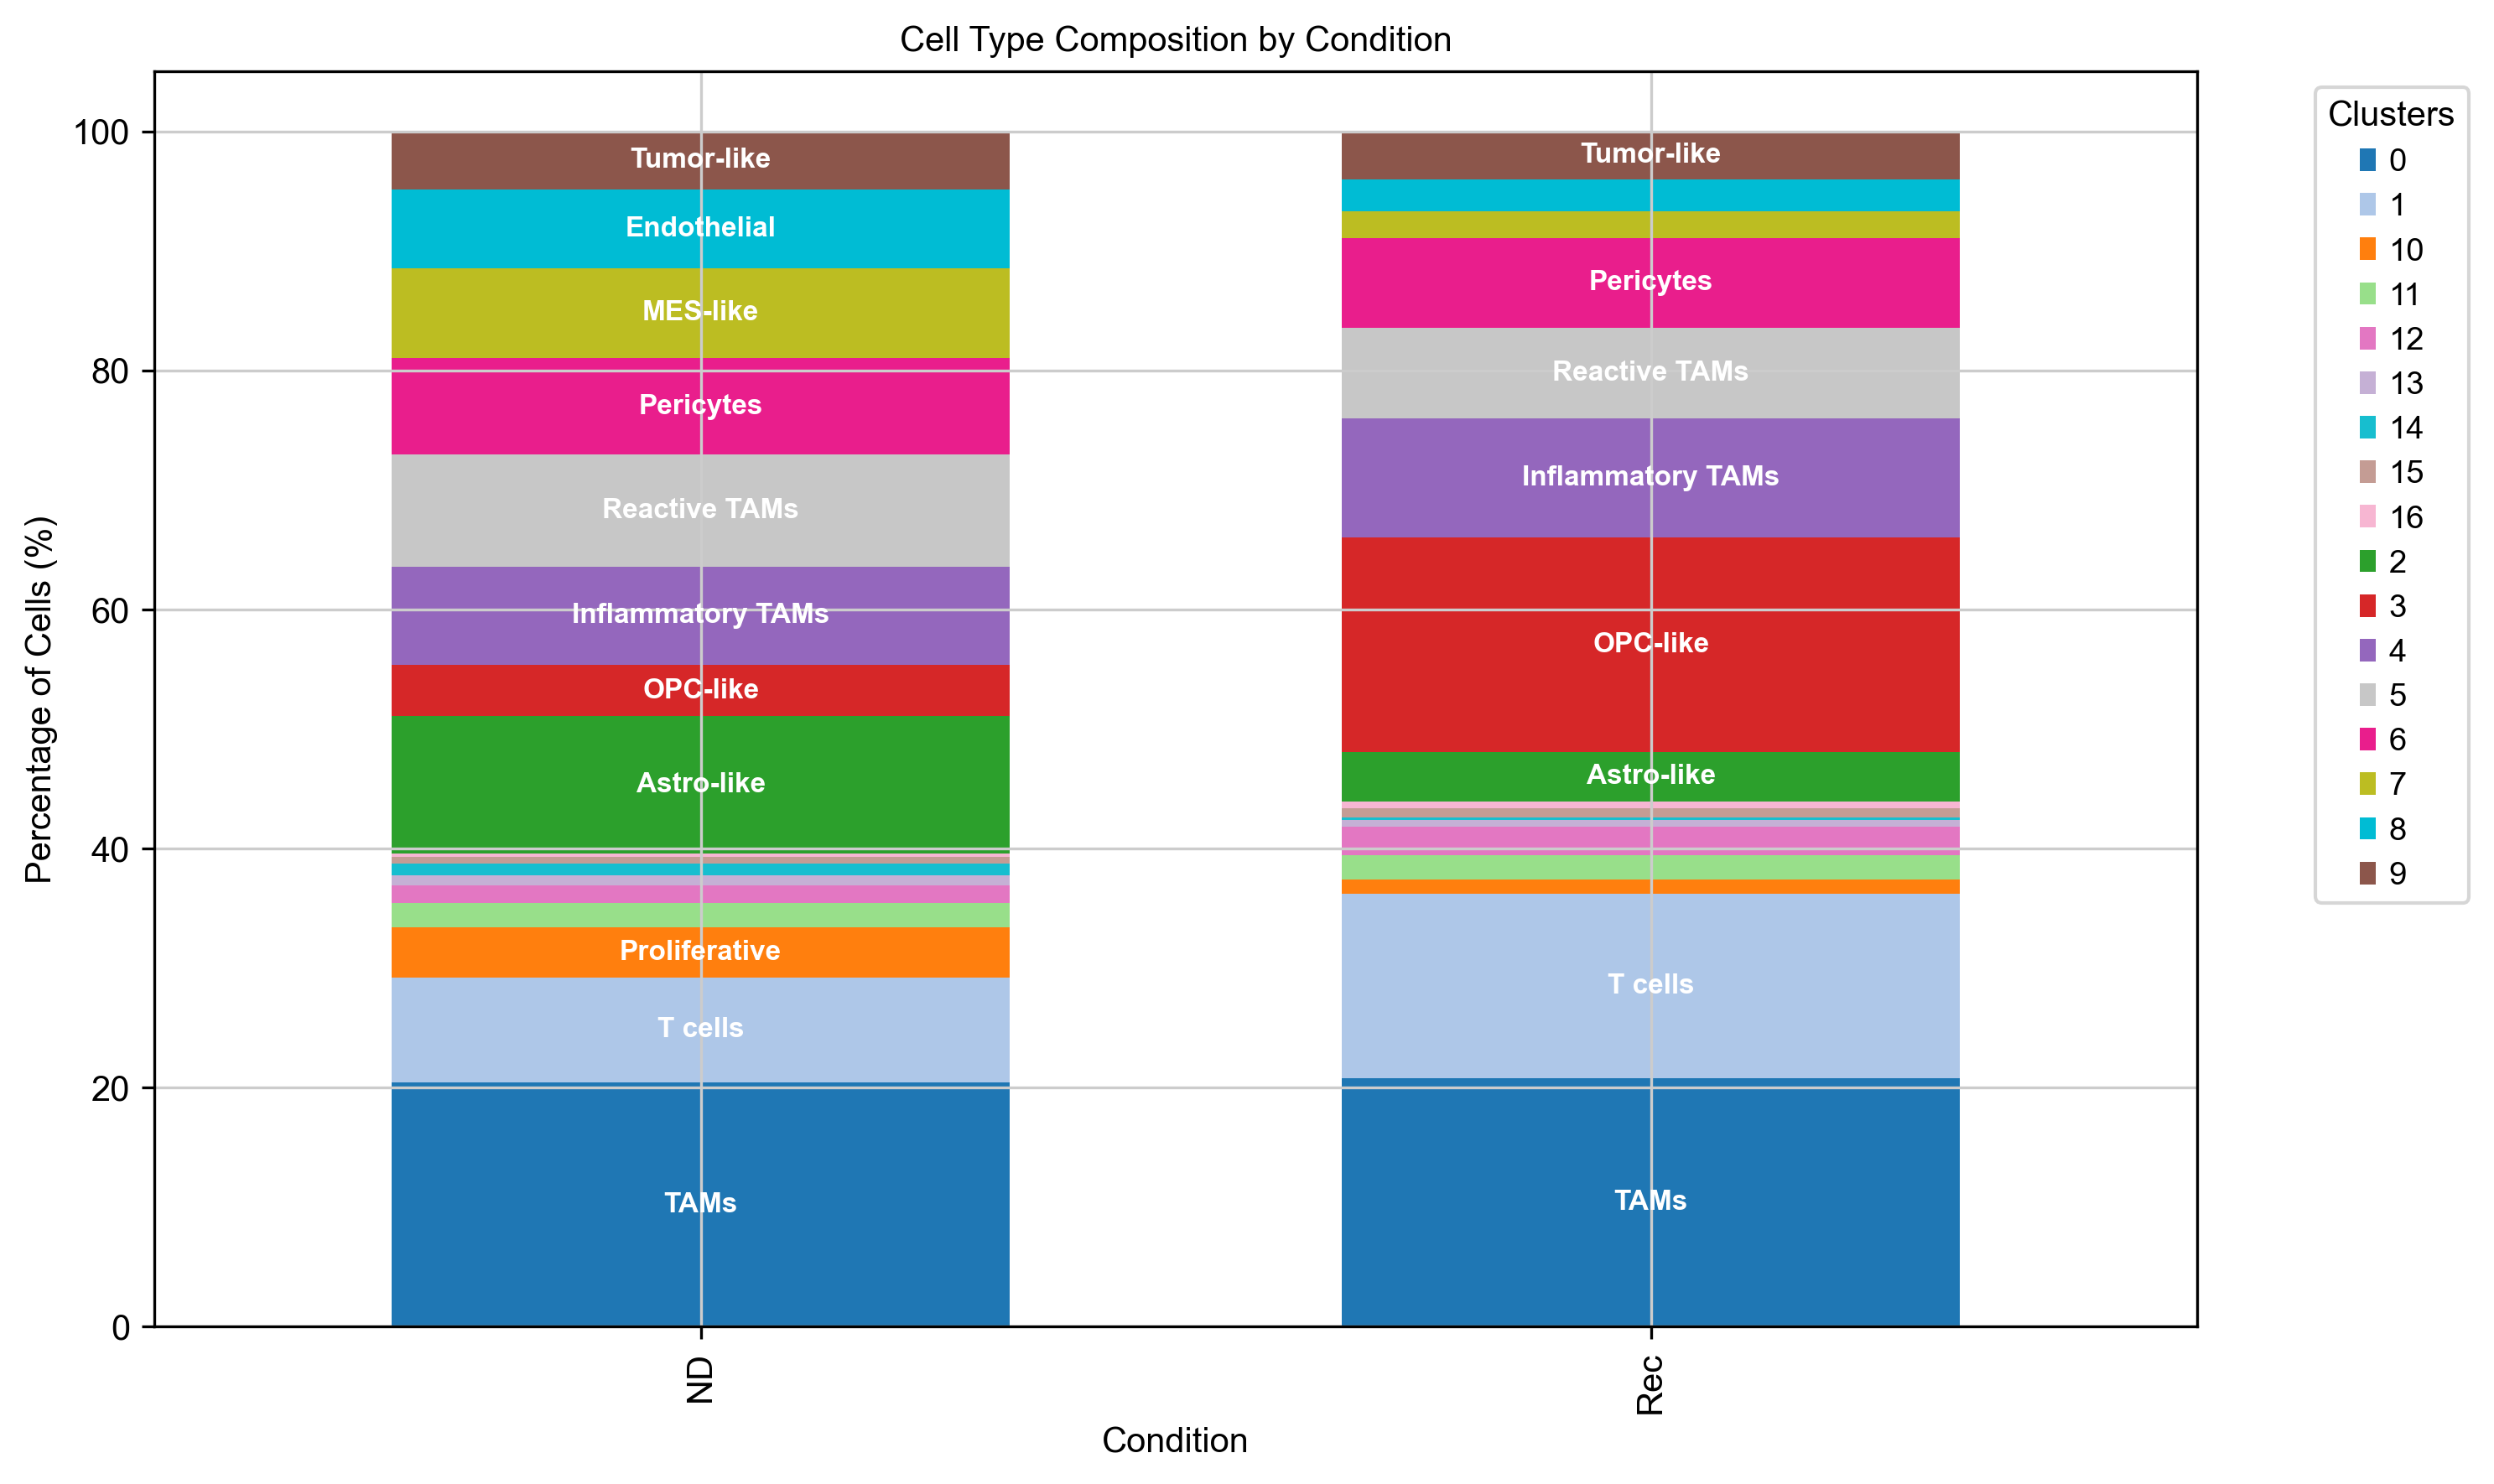

--- Proportion on Newly Diagnosed (%) ---
condition  Percentage
leiden               
0           20.396555
2           11.452033
5            9.345083
1            8.828360
4            8.251552


--- Proportion on Recurrent (%) ---
condition  Percentage
leiden               
0           20.785488
3           18.006324
1           15.435181
4            9.910135
5            7.596938


8796

In [ ]:
"""
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

adata=sc.read_h5ad(ckpt_dir / 'part5_annotated_adata_v2.h5ad')


# Crosstab in %
composition = pd.crosstab(
    adata.obs['leiden'].astype(str),
    adata.obs['condition'].astype(str),
    normalize='columns'
) * 100

# DataFrame for condition
df_denovo = composition[['ND']].copy().rename(columns={'ND': 'Percentage'})
df_recurrent = composition[['Rec']].copy().rename(columns={'Rec': 'Percentage'})

# Cluster -> cell type name
cluster_names = {

    # Myeloid compartment
    '0': 'TAMs',
    '4': 'Inflammatory TAMs',
    '5': 'Reactive TAMs',
    '11': 'Myeloid APCs',
    '14': 'Cycling',

    # Lymphoid compartment
    '1': 'T cells',
    '12': 'NK/Cytotoxic',
    '15': 'B cells',
    '16': 'Plasma cells',

    # Tumor compartment
    '2': 'Astro-like',
    '3': 'OPC-like',
    '7': 'MES-like',
    '9': 'Tumor-like',
    '10': 'Proliferative',

    # Vascular compartment
    '6': 'Pericytes',
    '8': 'Endothelial',
    '13': 'Activated Endothelial'
}

# Color palette matched from your UMAP figure
cell_type_colors = {
    'TAMs':                  '#1f77b4',  # steel blue
    'T cells':               '#aec7e8',  # light blue
    'Proliferative':         '#ff7f0e',  # orange
    'OPC-like':              '#d62728',  # red
    'Astro-like':            '#2ca02c',  # green
    'MES-like':              '#bcbd22',  # yellow-green/olive
    'Inflammatory TAMs':     '#9467bd',  # purple
    'Reactive TAMs':         '#c7c7c7',  # light grey
    'Myeloid APCs':          '#98df8a',  # light green
    'Cycling':               '#17becf',  # teal/cyan
    'Tumor-like':            '#8c564b',  # brown
    'NK/Cytotoxic':          '#e377c2',  # pink-magenta
    'B cells':               '#c49c94',  # light brown/mauve
    'Plasma cells':          '#f7b6d2',  # light pink
    'Endothelial':           '#00bcd4',  # bright cyan
    'Activated Endothelial': '#c5b0d5',  # light purple/lavender
    'Pericytes':             '#e91e8c',  # hot pink
}

# Plot
ax = composition.T.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=[cell_type_colors.get(cluster_names.get(str(cl), str(cl)), '#333333') for cl in composition.index],
    width=0.65
)

# Add labels inside each segment
for i, cond in enumerate(composition.columns):
    bottom = 0
    for cl in composition.index:
        val = composition.loc[cl, cond]
        if val >= 4:  # label only if big enough
            ax.text(
                i,
                bottom + val / 2,
                cluster_names.get(str(cl), str(cl)),
                ha='center',
                va='center',
                fontsize=8,
                rotation=0,
                color='white',
                fontweight='bold'
            )
        bottom += val

ax.set_title('Cell Type Composition by Condition')
ax.set_ylabel('Percentage of Cells (%)')
ax.set_xlabel('Condition')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Clusters')
plt.tight_layout()
plt.savefig('Comp_named_stacked_bar.pdf', bbox_inches='tight')
plt.show()

# Show df tables
print("--- Proportion on Newly Diagnosed (%) ---")
print(df_denovo.sort_values('Percentage', ascending=False).head())
print()
print("\n--- Proportion on Recurrent (%) ---")
print(df_recurrent.sort_values('Percentage', ascending=False).head())
del adata; gc.collect()